# spaCy NLP Pipeline — Real-World Data Edition

**Dataset:** 20 Newsgroups (sklearn) + Reuters Corpus (NLTK) — no API keys required  
**Focus:** spaCy pipeline fundamentals through to custom NER, EntityRuler, and evaluation  
**Level:** Beginner → Intermediate  

---

## What this notebook covers

| Section | Topic |
|---------|-------|
| 1 | Install & imports |
| 2 | Load real data (20 Newsgroups + Reuters) |
| 3 | Explore & visualise the corpus |
| 4 | Text cleaning & preprocessing |
| 5 | spaCy architecture & the Doc object |
| 6 | Tokenisation |
| 7 | Part-of-Speech (POS) tagging |
| 8 | Dependency parsing |
| 9 | Named Entity Recognition (NER) |
| 10 | EntityRuler — rule-based matching |
| 11 | Custom pipeline components |
| 12 | NER evaluation |
| 13 | End-to-end pipeline |

---

## Why real data matters

Synthetic (LLM-generated) data is convenient but it lacks the noise, variety, and edge cases found in
actual human writing. Real corpora like Reuters and 20 Newsgroups contain:
- Inconsistent capitalisation and abbreviations
- Domain jargon and rare proper nouns
- Ambiguous entities (e.g. *Apple* — fruit or company?)
- Natural class imbalance

These challenges are exactly what NLP models need to handle in production.

---
## Section 1 — Install Dependencies

Run this cell once. It installs every library we need:

| Package | Purpose |
|---------|--------|
| `spacy` | Core NLP library — tokeniser, tagger, NER, dependency parser |
| `en_core_web_sm` | Small English model trained on web text (news, blogs, comments) |
| `scikit-learn` | Provides the 20 Newsgroups dataset and evaluation metrics |
| `nltk` | Natural Language Toolkit — provides Reuters corpus |
| `pandas` | Data manipulation and display |
| `matplotlib` / `seaborn` | Visualisation |
| `wordcloud` | Word frequency cloud |
| `tqdm` | Progress bars for loops |

In [6]:
import subprocess, sys

# Install Python packages
packages = [
    'spacy',
    'scikit-learn',
    'nltk',
    'pandas',
    'matplotlib',
    'seaborn',
    'wordcloud',
    'tqdm',
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Download the spaCy English model (small — fast, ~12 MB)
# en_core_web_sm is trained on OntoNotes 5 (news + web)
subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'])

print('All dependencies installed.')


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 38.0 MB/s eta 0:00:00 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
All dependencies installed.



[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


---
## Section 2 — Load Real Data

### 2a: The 20 Newsgroups Dataset

The **20 Newsgroups** dataset is one of the most widely used benchmarks in text classification research.  
It contains ~18 000 newsgroup posts organised into 20 topics (e.g. `sci.space`, `comp.graphics`, `rec.sport.hockey`).  
It was collected from real Usenet forums in the early 1990s.

**Why it is good for practising NER:**  
News posts contain real mentions of people (`PERSON`), organisations (`ORG`), locations (`GPE`/`LOC`), and dates (`DATE`) — exactly what we want to extract.

### 2b: The Reuters Corpus

The **Reuters-21578** corpus from NLTK contains ~10 000 short newswire articles  
published by Reuters in 1987. Each article is tagged with one or more topics  
(e.g. `acq`, `earn`, `crude`, `trade`).  
Financial and business articles are particularly rich in `ORG`, `MONEY`, `DATE`, and `PERCENT` entities.

In [7]:
# ─── 2.1  Standard imports ───────────────────────────────────
import re
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm

# Matplotlib display settings
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Imports OK')

Imports OK


In [8]:
# ─── 2.2  Load 20 Newsgroups ─────────────────────────────────
from sklearn.datasets import fetch_20newsgroups

# We load only a subset of categories to keep runtime manageable
# These categories are entity-rich: politics, religion, sci, sports, tech
CATEGORIES = [
    'alt.atheism',
    'comp.graphics',
    'rec.sport.hockey',
    'sci.space',
    'soc.religion.christian',
    'talk.politics.misc',
    'talk.politics.guns',
]

# remove_headers strips email metadata so we only see the article body
news_train = fetch_20newsgroups(
    subset='train',
    categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),  # strip noise
    shuffle=True,
    random_state=42
)
news_test = fetch_20newsgroups(
    subset='test',
    categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=42
)

print(f'Training samples : {len(news_train.data)}')
print(f'Test samples     : {len(news_test.data)}')
print(f'Categories       : {news_train.target_names}')

Training samples : 3867
Test samples     : 2573
Categories       : ['alt.atheism', 'comp.graphics', 'rec.sport.hockey', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.misc']


In [9]:
# ─── 2.3  Load Reuters corpus from NLTK ─────────────────────
import nltk

# NLTK corpora are downloaded once to ~/nltk_data
nltk.download('reuters', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import reuters

# Reuters file IDs look like 'training/123' or 'test/456'
reuters_ids = reuters.fileids()   # list of all article IDs

# Get the categories available in Reuters
print(f'Total Reuters articles : {len(reuters_ids)}')
print(f'Unique topics          : {len(reuters.categories())}')
print(f'Sample topics          : {reuters.categories()[:10]}')

Total Reuters articles : 10788
Unique topics          : 90
Sample topics          : ['acq', 'alum', 'barley', 'bop', 'carcass', 'castor-oil', 'cocoa', 'coconut', 'coconut-oil', 'coffee']


In [10]:
# ─── 2.4  Build a unified document list ─────────────────────
# We combine both datasets into a single list of dicts.
# Each dict has keys: 'text', 'label', 'source'

ALL_DOCS = []

# -- Add 20 Newsgroups articles (first 500 per source)
for text, target_idx in zip(news_train.data[:500], news_train.target[:500]):
    label = news_train.target_names[target_idx]  # e.g. 'sci.space'
    ALL_DOCS.append({'text': text.strip(), 'label': label, 'source': '20newsgroups'})

# -- Add Reuters articles from earn/acq categories (business/finance are entity-rich)
for fid in reuters.fileids(categories=['earn', 'acq', 'crude', 'trade'])[:400]:
    raw = reuters.raw(fid)      # raw text of the article
    cats = reuters.categories(fid)  # list of topic tags
    ALL_DOCS.append({'text': raw.strip(), 'label': cats[0], 'source': 'reuters'})

# Shuffle so both sources are mixed
random.seed(42)
random.shuffle(ALL_DOCS)

print(f'Combined corpus size: {len(ALL_DOCS)} documents')
print()

# Quick sanity check — show one document from each source
for source in ['20newsgroups', 'reuters']:
    example = next(d for d in ALL_DOCS if d['source'] == source)
    print(f'=== Source: {source} | Label: {example["label"]} ===')
    print(example['text'][:300])
    print()

Combined corpus size: 900 documents

=== Source: 20newsgroups | Label: rec.sport.hockey ===
I didn't see any smilies in this message so.......

                W     T    L    PTs
   Team A      50    30    4    104
   Team B      52    32    0    104


There you go.  Two teams that tie in points without identical records.

=== Source: reuters | Label: earn ===
JAMES RIVER CORP &lt;JR> SETS REGULAR PAYOUT
  Qtrly div 10 cts vs 10 cts prior
      Pay April 30
      Record April 21



---
## Section 3 — Explore the Corpus

Before building any model, always **understand your data** first.  
Key questions to answer:
1. How many documents per category? (Class balance)
2. How long are the documents? (Affects processing speed)
3. What words appear most often? (Domain vocabulary)

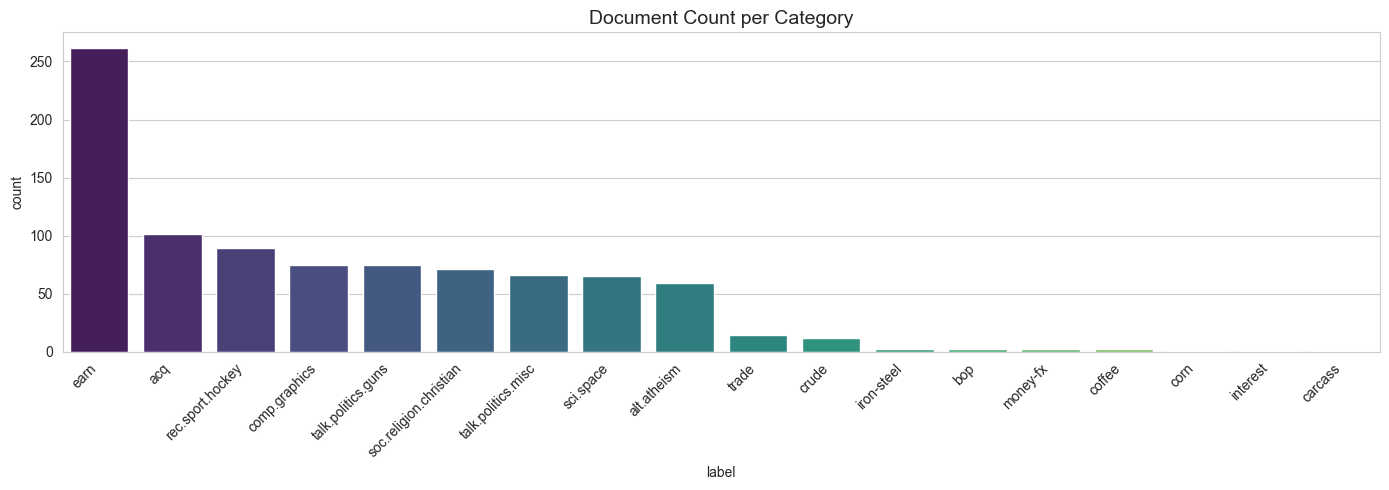

Top 5 categories:
                label  count
1                earn    262
9                 acq    101
0    rec.sport.hockey     89
3       comp.graphics     75
4  talk.politics.guns     75


In [11]:
# ─── 3.1  Class distribution ─────────────────────────────────
# Count how many documents belong to each label
label_counts = Counter(d['label'] for d in ALL_DOCS)

# Convert to a DataFrame for easy plotting
df_labels = pd.DataFrame(label_counts.items(), columns=['label', 'count'])
df_labels = df_labels.sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=df_labels, x='label', y='count', palette='viridis', ax=ax)
ax.set_title('Document Count per Category', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 5 categories:')
print(df_labels.head())

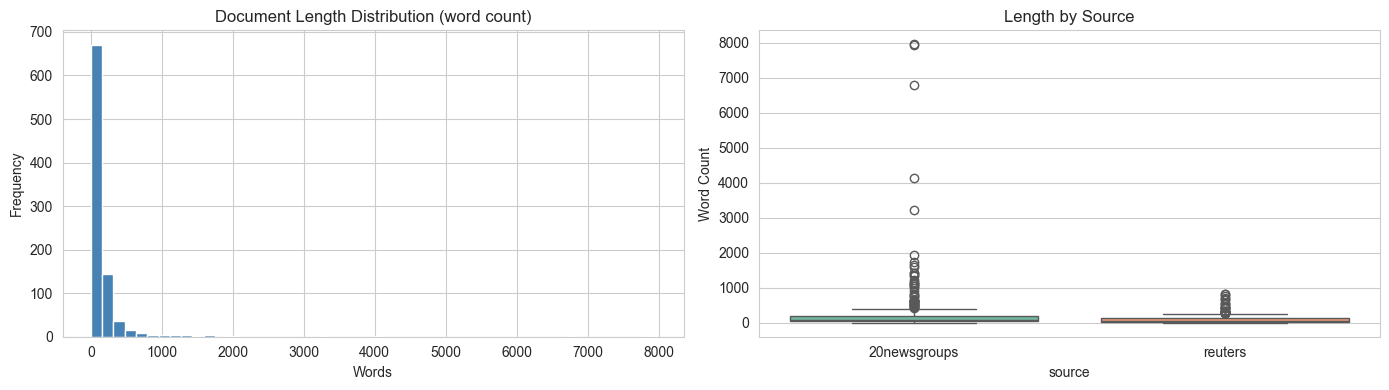

Mean  : 176 words
Median: 80 words
Max   : 7952 words


In [12]:
# ─── 3.2  Document length distribution ───────────────────────
# We measure length by word count — a rough but fast proxy

lengths = [len(d['text'].split()) for d in ALL_DOCS]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram — raw lengths
axes[0].hist(lengths, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Document Length Distribution (word count)')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Frequency')

# Box plot — compare lengths by source
df_len = pd.DataFrame({'words': lengths, 'source': [d['source'] for d in ALL_DOCS]})
sns.boxplot(data=df_len, x='source', y='words', palette='Set2', ax=axes[1])
axes[1].set_title('Length by Source')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

print(f'Mean  : {np.mean(lengths):.0f} words')
print(f'Median: {np.median(lengths):.0f} words')
print(f'Max   : {np.max(lengths)} words')

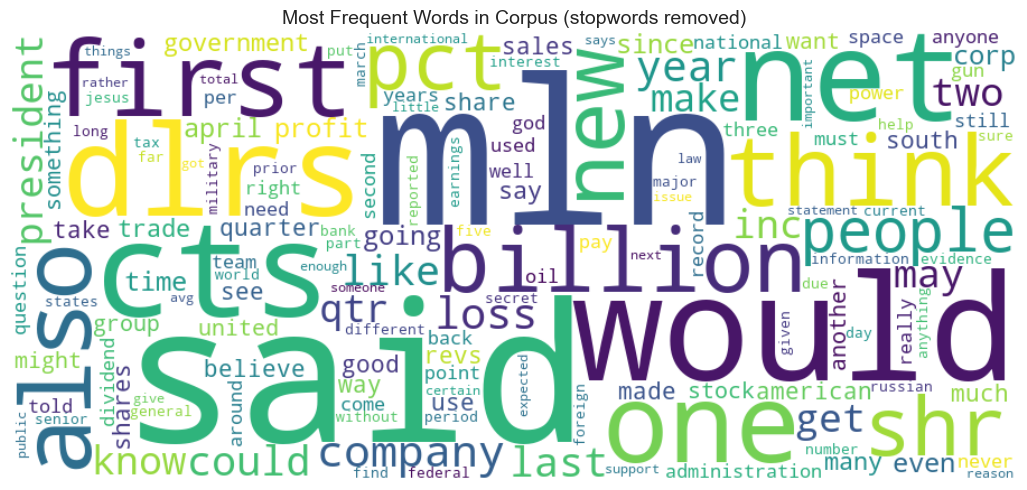

Top 20 words:
[('mln', 747), ('said', 679), ('would', 549), ('cts', 444), ('net', 402), ('dlrs', 401), ('one', 305), ('first', 259), ('think', 256), ('also', 255), ('billion', 254), ('new', 247), ('shr', 216), ('pct', 209), ('people', 206), ('company', 205), ('loss', 199), ('year', 191), ('like', 180), ('could', 177)]


In [13]:
# ─── 3.3  Most frequent words (after removing stopwords) ─────
from nltk.corpus import stopwords
from wordcloud import WordCloud

STOPWORDS = set(stopwords.words('english'))

# Concatenate all text and tokenise by whitespace (fast)
all_text = ' '.join(d['text'] for d in ALL_DOCS)
words = [
    w.lower() for w in all_text.split()
    if w.isalpha()                  # keep only alphabetic tokens
    and w.lower() not in STOPWORDS  # drop common words like 'the', 'is'
    and len(w) > 2                  # drop single/double-char tokens
]

word_freq = Counter(words)

# Word cloud
wc = WordCloud(width=900, height=400, background_color='white', max_words=150)
wc.generate_from_frequencies(word_freq)

plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Corpus (stopwords removed)', fontsize=14)
plt.tight_layout()
plt.show()

print('Top 20 words:')
print(word_freq.most_common(20))

---
## Section 4 — Text Cleaning and Preprocessing

### Why do we clean text?

Raw text from the internet contains:
- Email headers, HTML tags, and boilerplate noise
- Inconsistent whitespace and special characters
- URLs and email addresses that carry no meaning for most NLP tasks

Cleaning reduces vocabulary size and helps the model focus on meaningful tokens.

> **Important:** spaCy's own tokeniser handles most punctuation correctly, so we do *minimal* cleaning
> before passing text to spaCy — we do NOT lowercase (spaCy needs the original case for NER).

In [14]:
# ─── 4.1  Text cleaning function ────────────────────────────
def clean_text(text: str, for_spacy: bool = True) -> str:
    """
    Light-touch cleaning suitable for NER tasks.

    Args:
        text: raw document string
        for_spacy: if True, preserve original case (NER needs it)
                   if False, also lowercase the result

    Returns:
        Cleaned string ready for NLP processing
    """
    # Remove URLs — they are noisy and rarely carry entity information
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove lines that look like email/newsgroup headers (e.g. 'From: user...')
    text = re.sub(r'^(From|Subject|Organization|Lines|In-Reply-To):.*$',
                  '', text, flags=re.MULTILINE)

    # Collapse multiple blank lines into a single newline
    text = re.sub(r'\n{2,}', '\n', text)

    # Normalise whitespace within lines
    text = re.sub(r'[ \t]+', ' ', text)

    # Strip leading/trailing whitespace
    text = text.strip()

    # Optionally lowercase (NOT for NER — breaks capitalisation cues)
    if not for_spacy:
        text = text.lower()

    return text


# Apply cleaning to every document in our corpus
for doc in ALL_DOCS:
    doc['clean_text'] = clean_text(doc['text'])

# Show before / after on one document
sample = ALL_DOCS[0]
print('=== BEFORE cleaning ===')
print(sample['text'][:400])
print()
print('=== AFTER  cleaning ===')
print(sample['clean_text'][:400])

=== BEFORE cleaning ===
I didn't see any smilies in this message so.......

                W     T    L    PTs
   Team A      50    30    4    104
   Team B      52    32    0    104


There you go.  Two teams that tie in points without identical records.

=== AFTER  cleaning ===
I didn't see any smilies in this message so.......
 W T L PTs
 Team A 50 30 4 104
 Team B 52 32 0 104
There you go. Two teams that tie in points without identical records.


---
## Section 5 — spaCy Architecture and the Doc Object

### How spaCy works

When you call `nlp(text)`, your text passes through a **pipeline** of components:

```
raw text
   │
   ▼
┌─────────────┐   Splits text into Token objects by whitespace/punctuation rules
│  tokenizer  │
└──────┬──────┘
       │
       ▼
┌─────────────┐   Assigns part-of-speech tags (NOUN, VERB, ADJ…)
│   tagger    │
└──────┬──────┘
       │
       ▼
┌─────────────┐   Assigns fine-grained dependency labels (nsubj, dobj…)
│   parser    │
└──────┬──────┘
       │
       ▼
┌─────────────┐   Assigns named entity spans (PERSON, ORG, GPE…)
│     ner     │
└──────┬──────┘
       │
       ▼
   Doc object  ← everything lives here
```

### The Doc object

A `Doc` is a sequence of `Token` objects. Every token stores:

| Attribute | Description | Example |
|-----------|-------------|--------|
| `token.text` | Original string | `"NASA"` |
| `token.lemma_` | Base (dictionary) form | `"nasa"` |
| `token.pos_` | Coarse POS tag | `"PROPN"` |
| `token.tag_` | Fine-grained POS tag | `"NNP"` |
| `token.dep_` | Dependency label | `"nsubj"` |
| `token.is_stop` | Is it a stopword? | `False` |
| `token.ent_type_` | Named entity type | `"ORG"` |

In [15]:
# ─── 5.1  Load spaCy and inspect the default pipeline ────────
import spacy
from spacy import displacy

# en_core_web_sm is the small English model (~12 MB)
# Other options: en_core_web_md (medium), en_core_web_lg (large — more accurate)
nlp = spacy.load('en_core_web_sm')

print('Pipeline components:', nlp.pipe_names)
# Expected output: ['tok2vec', 'tagger', 'parser', 'senter', 'ner', 'attribute_ruler', 'lemmatizer']

print()
print('Supported entity types:')
print(nlp.get_pipe('ner').labels)

Pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

Supported entity types:
('CARDINAL', 'DATE', 'EVENT', 'FAC', 'GPE', 'LANGUAGE', 'LAW', 'LOC', 'MONEY', 'NORP', 'ORDINAL', 'ORG', 'PERCENT', 'PERSON', 'PRODUCT', 'QUANTITY', 'TIME', 'WORK_OF_ART')


In [16]:
# ─── 5.2  Process a document and inspect the Doc object ──────

# Pick a Reuters article — short, entity-rich
reuters_doc = next(d for d in ALL_DOCS if d['source'] == 'reuters')
sample_text = reuters_doc['clean_text'][:500]   # use first 500 chars

print('Input text:')
print(sample_text)
print()

# Run the full pipeline
doc = nlp(sample_text)

print(f'Number of tokens  : {len(doc)}')
print(f'Number of sentences: {len(list(doc.sents))}')
print(f'Number of entities : {len(doc.ents)}')
print()

# Token-level inspection
print(f'{"Token":<20} {"Lemma":<20} {"POS":<10} {"Tag":<8} {"Stop?":<6} {"Entity"}')
print('-' * 75)
for token in doc[:20]:  # first 20 tokens
    print(f'{token.text:<20} {token.lemma_:<20} {token.pos_:<10} '
          f'{token.tag_:<8} {str(token.is_stop):<6} {token.ent_type_}')

Input text:
JAMES RIVER CORP &lt;JR> SETS REGULAR PAYOUT
 Qtrly div 10 cts vs 10 cts prior
 Pay April 30
 Record April 21

Number of tokens  : 26
Number of sentences: 1
Number of entities : 7

Token                Lemma                POS        Tag      Stop?  Entity
---------------------------------------------------------------------------
JAMES                JAMES                PROPN      NNP      False  ORG
RIVER                RIVER                PROPN      NNP      False  ORG
CORP                 CORP                 PROPN      NNP      False  ORG
&                    &                    CCONJ      CC       False  ORG
lt;JR                lt;JR                PROPN      NNP      False  ORG
>                    >                    X          XX       False  ORG
SETS                 SETS                 PROPN      NNP      False  ORG
REGULAR              REGULAR              PROPN      NNP      False  ORG
PAYOUT               PAYOUT               PROPN      NNP      False  OR

---
## Section 6 — Tokenisation

### What is tokenisation?

**Tokenisation** is the process of splitting a string of text into individual units called *tokens*.  
A token is usually a word, but it can also be a punctuation mark, number, or whitespace.

### How spaCy tokenises

spaCy uses a **rule-based tokeniser** that applies:
1. **Prefix rules** — strips leading punctuation (e.g. `(NASA` → `(` + `NASA`)
2. **Suffix rules** — strips trailing punctuation (e.g. `said.` → `said` + `.`)
3. **Infix rules** — splits on hyphens, slashes (e.g. `well-known` → `well` + `-` + `known`)
4. **Exception rules** — keeps contractions and abbreviations intact (e.g. `U.S.` stays as one token)

This is more linguistically aware than simply splitting on whitespace.

In [17]:
# ─── 6.1  Compare spaCy tokenisation with simple split ────────

# A sentence that shows spaCy's advantages over naive splitting
test_sentences = [
    "The U.S. Senate voted 51-49 on the bill.",
    "NASA's Artemis mission cost $93bn according to the GAO.",
    "She said, \"It's well-known that I.B.M. invested heavily.\"",
]

for sent in test_sentences:
    print(f'Text: {sent}')

    # Naive split on whitespace
    naive = sent.split()
    print(f'  Naive split ({len(naive)} tokens): {naive}')

    # spaCy tokenisation
    spacy_tokens = [t.text for t in nlp(sent)]
    print(f'  spaCy tokens ({len(spacy_tokens)} tokens): {spacy_tokens}')
    print()

Text: The U.S. Senate voted 51-49 on the bill.
  Naive split (8 tokens): ['The', 'U.S.', 'Senate', 'voted', '51-49', 'on', 'the', 'bill.']
  spaCy tokens (11 tokens): ['The', 'U.S.', 'Senate', 'voted', '51', '-', '49', 'on', 'the', 'bill', '.']

Text: NASA's Artemis mission cost $93bn according to the GAO.
  Naive split (9 tokens): ["NASA's", 'Artemis', 'mission', 'cost', '$93bn', 'according', 'to', 'the', 'GAO.']
  spaCy tokens (12 tokens): ['NASA', "'s", 'Artemis', 'mission', 'cost', '$', '93bn', 'according', 'to', 'the', 'GAO', '.']

Text: She said, "It's well-known that I.B.M. invested heavily."
  Naive split (8 tokens): ['She', 'said,', '"It\'s', 'well-known', 'that', 'I.B.M.', 'invested', 'heavily."']
  spaCy tokens (15 tokens): ['She', 'said', ',', '"', 'It', "'s", 'well', '-', 'known', 'that', 'I.B.M.', 'invested', 'heavily', '.', '"']



In [18]:
# ─── 6.2  Sentence tokenisation ──────────────────────────────
# spaCy's parser also detects sentence boundaries

reuters_sample = next(d for d in ALL_DOCS if d['source'] == 'reuters')
full_doc = nlp(reuters_sample['clean_text'][:800])

sentences = list(full_doc.sents)  # generator → list

print(f'Document snippet ({len(full_doc)} tokens) split into {len(sentences)} sentences:')
print()
for i, sent in enumerate(sentences, 1):
    print(f'  S{i}: {sent.text.strip()}')

Document snippet (26 tokens) split into 1 sentences:

  S1: JAMES RIVER CORP &lt;JR> SETS REGULAR PAYOUT
 Qtrly div 10 cts vs 10 cts prior
 Pay April 30
 Record April 21


---
## Section 7 — Part-of-Speech (POS) Tagging

### What is POS tagging?

**Part-of-speech tagging** assigns a grammatical category (noun, verb, adjective, etc.) to each token.  
These tags are critical for:
- NER (proper nouns are likely entity candidates)
- Information extraction (verbs signal relationships)
- Text summarisation (content words vs. function words)

### Two tag sets in spaCy

| Attribute | Tag set | Example |
|-----------|---------|--------|
| `token.pos_` | Universal POS (coarse, 17 tags) | `NOUN`, `VERB`, `PROPN` |
| `token.tag_` | Penn Treebank (fine-grained, 36+ tags) | `NN`, `VBD`, `NNP` |

Common coarse tags: `NOUN`, `PROPN` (proper noun), `VERB`, `ADJ`, `ADV`, `DET`, `PUNCT`, `NUM`, `ADP` (preposition)

POS tagging: 100%|██████████| 100/100 [00:00<00:00, 184.75it/s]


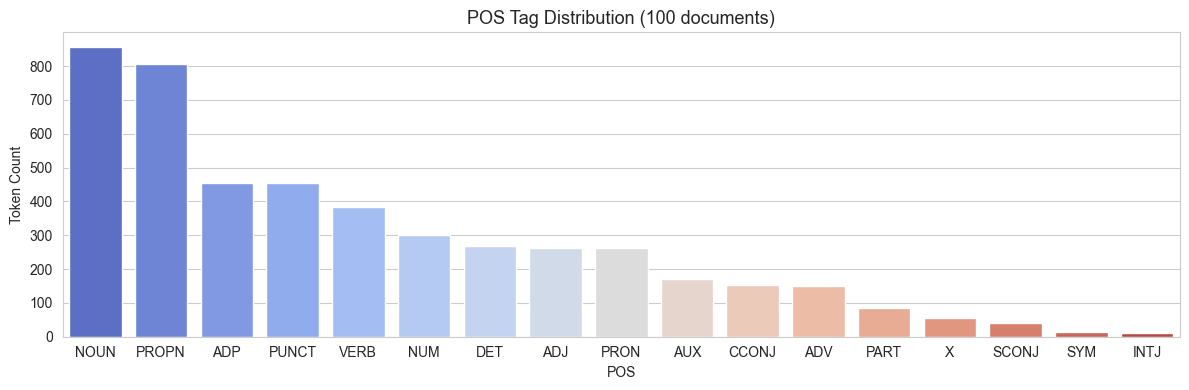

In [19]:
# ─── 7.1  POS tag frequency across the corpus ─────────────────

# Process a batch of 100 documents with nlp.pipe (much faster than a loop)
# batch_size controls how many docs are processed at once in memory
sample_docs = [d['clean_text'][:300] for d in ALL_DOCS[:100]]

pos_counter = Counter()

for doc in tqdm(nlp.pipe(sample_docs, batch_size=32), total=100, desc='POS tagging'):
    for token in doc:
        if not token.is_space:           # skip whitespace tokens
            pos_counter[token.pos_] += 1 # count each coarse POS tag

# Plot
pos_df = pd.DataFrame(pos_counter.items(), columns=['POS', 'count'])
pos_df = pos_df.sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=pos_df, x='POS', y='count', palette='coolwarm', ax=ax)
ax.set_title('POS Tag Distribution (100 documents)', fontsize=13)
ax.set_ylabel('Token Count')
plt.tight_layout()
plt.show()

In [20]:
# ─── 7.2  Extract noun phrases (noun chunks) ──────────────────
# Noun chunks are spans like 'the space shuttle', 'NASA scientists'
# They are useful for extracting key concepts without full syntactic parsing

news_sample = next(d for d in ALL_DOCS if 'sci.space' in d['label'])
news_doc = nlp(news_sample['clean_text'][:600])

print('Input text:')
print(news_doc.text)
print()

print('Noun chunks (key phrases):')
for chunk in news_doc.noun_chunks:
    # chunk.root.dep_ tells us the grammatical role of the head noun
    print(f'  "{chunk.text}"  (root: "{chunk.root.text}", dep: {chunk.root.dep_})')

Input text:
I was wondering if the FAQ files could be posted quarterly rather than monthly. Every 28-30 days, I get this bloated feeling.

Noun chunks (key phrases):
  "I"  (root: "I", dep: nsubj)
  "the FAQ files"  (root: "files", dep: nsubjpass)
  "I"  (root: "I", dep: nsubj)
  "this bloated feeling"  (root: "feeling", dep: dobj)


---
## Section 8 — Dependency Parsing

### What is dependency parsing?

**Dependency parsing** builds a tree that shows *grammatical relationships* between words.  
Each token (except the root verb) has an *arc* pointing to its syntactic head.

Example tree for `"NASA launched the rocket."`:  
```
         launched          ← ROOT (main verb)
        /        \
      NASA        rocket   ← nsubj (subject), dobj (direct object)
                  |
                 the       ← det (determiner)
```

### Why it matters for NLP

Dependency structure lets us:
- Find the subject of a verb (who did what?)
- Extract (subject, verb, object) triples for knowledge graphs
- Identify which adjective modifies which noun

In [21]:
# ─── 8.1  Dependency tree for a real sentence ────────────────

# Grab a short, clean sentence from Reuters
for doc_data in ALL_DOCS:
    if doc_data['source'] == 'reuters':
        clean = doc_data['clean_text']
        # Find a sentence that is not too long (50-120 chars)
        for line in clean.split('\n'):
            line = line.strip()
            if 50 < len(line) < 120:
                good_sentence = line
                break
        else:
            continue
        break

print('Sentence:', good_sentence)
print()

dep_doc = nlp(good_sentence)

# Print dependency table
print(f'{"Token":<15} {"Head":<15} {"Dep Label":<12} {"POS"}')
print('-' * 55)
for token in dep_doc:
    print(f'{token.text:<15} {token.head.text:<15} {token.dep_:<12} {token.pos_}')

Sentence: &lt;FIRST MERCANTILE CURRENCY FUND INC> 1ST QTR NET

Token           Head            Dep Label    POS
-------------------------------------------------------
&               NET             cc           CCONJ
lt;FIRST        1ST             compound     PROPN
MERCANTILE      1ST             compound     PROPN
CURRENCY        1ST             compound     PROPN
FUND            1ST             compound     PROPN
INC             1ST             compound     PROPN
>               1ST             nmod         PROPN
1ST             NET             compound     NUM
QTR             NET             compound     PROPN
NET             NET             ROOT         PROPN


In [22]:
# ─── 8.2  Subject-Verb-Object extraction ─────────────────────
# A practical application: extract who did what to whom

def extract_svo(doc) -> list:
    """
    Extract (subject, verb, object) triples from a spaCy Doc.

    Strategy:
    - Find all verbs that have a nominal subject (nsubj) and a direct object (dobj)
    - Return them as (subject_text, verb_text, object_text)

    Note: This is a simplified heuristic — full relation extraction is more complex.
    """
    triples = []
    for token in doc:
        # Is this a main verb?
        if token.pos_ in ('VERB', 'AUX') and token.dep_ in ('ROOT', 'relcl'):
            subj = None
            obj  = None

            for child in token.children:
                if child.dep_ in ('nsubj', 'nsubjpass'):   # subject
                    subj = child.text
                if child.dep_ in ('dobj', 'pobj', 'attr'): # object
                    obj = child.text

            if subj and obj:
                triples.append((subj, token.lemma_, obj))

    return triples


# Run on a few Reuters articles
print('Subject–Verb–Object triples extracted from Reuters articles:')
print('=' * 60)
count = 0
for doc_data in ALL_DOCS:
    if doc_data['source'] != 'reuters':
        continue
    d = nlp(doc_data['clean_text'][:500])
    triples = extract_svo(d)
    for t in triples:
        print(f'  {t[0]:20} --[{t[1]}]-->  {t[2]}')
        count += 1
    if count >= 15:
        break

Subject–Verb–Object triples extracted from Reuters articles:
  LOSS                 --[gain]-->  >
  bill                 --[repeal]-->  pricing
  Cosentino            --[tell]-->  analysts
  Corp                 --[tell]-->  Commission
  PROBE                --[launch]-->  investigation
  net                  --[exclude]-->  credit
  Net                  --[exclude]-->  investment
  which                --[own]-->  pct
  Group                --[file]-->  materials
  Andover              --[express]-->  interest
  parent               --[acquire]-->  pub
  DISTILLERS           --[see]-->  GAIN
  dividend             --[include]-->  cts
  decision             --[reduce]-->  income
  excludes             --[gain]-->  dlrs


---
## Section 9 — Named Entity Recognition (NER)

### What is NER?

**Named Entity Recognition** is the task of locating and classifying *named entities* in text  
into predefined categories such as person names, organisations, locations, dates, and monetary values.

Example:  
```
"Apple acquired Intel's modem business for $1 billion in October 2019."
                                                                        
 Apple     → ORG   (organisation)
 Intel     → ORG
 $1 billion→ MONEY
 October 2019 → DATE
```

### spaCy's entity types (OntoNotes 5 label set)

| Label | Meaning |
|-------|--------|
| `PERSON` | People, including fictional |
| `ORG` | Companies, agencies, institutions |
| `GPE` | Countries, cities, states (Geopolitical Entity) |
| `LOC` | Non-GPE locations (mountains, bodies of water) |
| `DATE` | Absolute or relative dates |
| `TIME` | Times smaller than a day |
| `MONEY` | Monetary values including currency |
| `PERCENT` | Percentage |
| `NORP` | Nationalities, religious/political groups |
| `PRODUCT` | Objects, vehicles, foods |
| `EVENT` | Named events (wars, elections, etc.) |
| `LAW` | Named laws and legal documents |

### How NER models work

spaCy uses a **transition-based** NER system.  
The model reads tokens left-to-right and decides for each token whether it:
- **B**egins a new entity span
- Is **I**nside an ongoing entity span
- Is **O**utside any entity

This BIO (or IOB2) tagging scheme is the standard format for sequence labelling.

In [23]:
# ─── 9.1  Run NER on real news text ───────────────────────────

# Select a Reuters article that mentions companies, money, and dates
rich_doc = next(
    d for d in ALL_DOCS
    if d['source'] == 'reuters' and 'acq' in d['label']  # acquisition articles = entity-rich
)

text = rich_doc['clean_text'][:600]
doc = nlp(text)

print('Text:')
print(text)
print()

print(f'{"Entity Text":<35} {"Label":<12} {"Start":<7} {"End":<7} {"Explanation"}')
print('-' * 80)
for ent in doc.ents:
    explanation = spacy.explain(ent.label_) or ''  # human-readable label description
    print(f'{ent.text:<35} {ent.label_:<12} {ent.start_char:<7} {ent.end_char:<7} {explanation}')

Text:
FLUOROCARBON &lt;FCBN> BUYS EATON &lt;ETN> DIVISION
 Fluorocarbon Co said it
 signed a definitive agreement to acquire Eaton Corp's
 Industrial Polymer division for an undisclosed price.
 The polymer division, based in Aurora, Ohio, had 1986 sales
 of 86 mln dlrs, Fluorocarbon also said.

Entity Text                         Label        Start   End     Explanation
--------------------------------------------------------------------------------
FLUOROCARBON &lt;FCBN> BUYS EATON &lt;ETN> DIVISION
 Fluorocarbon Co ORG          0       68      Companies, agencies, institutions, etc.
Eaton Corp's                        ORG          119     131     Companies, agencies, institutions, etc.
Aurora                              GPE          219     225     Countries, cities, states
Ohio                                GPE          227     231     Countries, cities, states
1986                                DATE         237     241     Absolute or relative dates or periods
86                

NER: 100%|██████████| 900/900 [00:05<00:00, 151.39it/s]


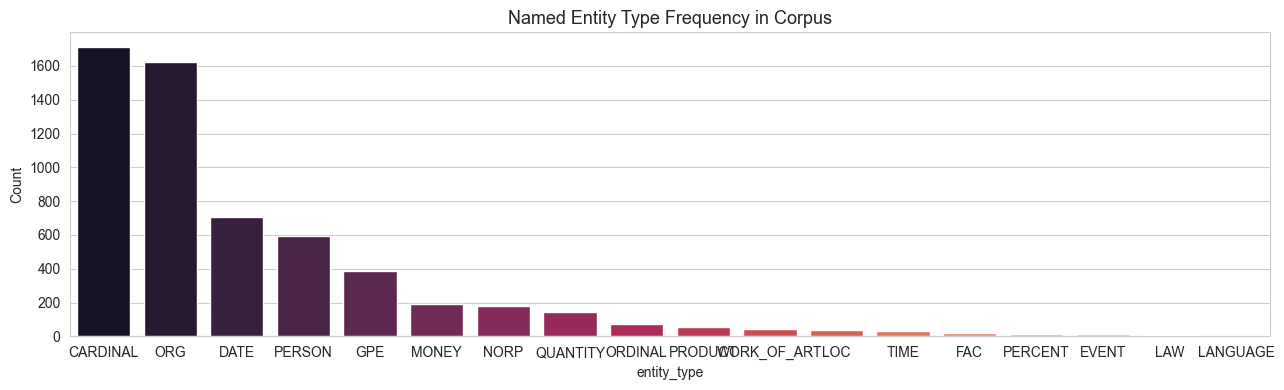

Top ORG: ['cts', 'CTS', 'NET\n Shr', 'DLRS', 'GM']
Top PERSON: ['Jesus', 'Roger', 'Clinton', 'Keenan', 'Datron']
Top GPE: ['U.S.', 'Japan', 'Texas', 'Brazil', 'New York']
Top MONEY: ['#', '# \n#', '2.55 billion', '480 mln marks', '23.7 mln']
Top DATE: ['1986', '1987', 'today', '1985', 'last year']


In [24]:
# ─── 9.2  Entity frequency analysis across entire corpus ─────
# Process all documents and count entity type occurrences

entity_type_counter = Counter()
entity_text_by_type = {}  # entity_type -> list of raw entity strings

texts = [d['clean_text'][:400] for d in ALL_DOCS]   # limit each doc to 400 chars

for doc in tqdm(nlp.pipe(texts, batch_size=64), total=len(texts), desc='NER'):
    for ent in doc.ents:
        entity_type_counter[ent.label_] += 1
        entity_text_by_type.setdefault(ent.label_, []).append(ent.text)

# Plot entity type distribution
ent_df = pd.DataFrame(entity_type_counter.items(), columns=['entity_type', 'count'])
ent_df = ent_df.sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(13, 4))
sns.barplot(data=ent_df, x='entity_type', y='count', palette='rocket', ax=ax)
ax.set_title('Named Entity Type Frequency in Corpus', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Show top 10 entity strings per type
for etype in ['ORG', 'PERSON', 'GPE', 'MONEY', 'DATE']:
    top = Counter(entity_text_by_type.get(etype, [])).most_common(5)
    print(f'Top {etype}: {[t for t, _ in top]}')

In [25]:
# ─── 9.3  Visualise NER with displacy ────────────────────────
# displacy renders a colour-coded HTML annotation view

vis_text = rich_doc['clean_text'][:400]
vis_doc = nlp(vis_text)

# In a Jupyter notebook, displacy.render() shows an inline HTML display
displacy.render(vis_doc, style='ent', jupyter=True)

---
## Section 10 — EntityRuler: Rule-Based NER

### Why add rule-based matching?

spaCy's statistical NER model is trained on news text and is good at general entity types.  
However, it **misses domain-specific entities** such as:
- Custom product codes or invoice numbers (`INV-2024-001`)
- Stock ticker symbols (`$AAPL`, `MSFT`)
- Structured identifiers (ISIN codes, regulatory IDs)

The **EntityRuler** component lets you define patterns using:
1. **Exact string matches** — `{"lower": "nasa"}`
2. **Regex patterns** — `{"TEXT": {"REGEX": "\\$[A-Z]{2,5}"}}`
3. **Token attribute combos** — `{"POS": "PROPN", "DEP": "nsubj"}`

Patterns are checked **before** (or after) the statistical NER, giving you full control.

In [26]:
# ─── 10.1  Build a custom EntityRuler pipeline ────────────────
from spacy.pipeline import EntityRuler

# Create a fresh pipeline — we disable the built-in NER so the ruler
# runs first, then we re-add ner at the end
nlp_custom = spacy.load('en_core_web_sm')

# Add EntityRuler BEFORE the NER component
# overwrite_ents=False means the ruler won't replace entities already found
ruler = nlp_custom.add_pipe('entity_ruler', before='ner', config={'overwrite_ents': False})

# ── Define domain-specific patterns ──────────────────────────
patterns = [
    # Stock ticker symbols (e.g. $AAPL, $MSFT, $IBM)
    # Pattern: dollar sign token followed by 2-5 uppercase letters
    {'label': 'TICKER',
     'pattern': [{'TEXT': '$'}, {'TEXT': {'REGEX': '^[A-Z]{2,5}$'}}]},

    # Reuters deal identifiers — numbers followed by 'mln' or 'bln' (Reuters style)
    # e.g. '2.3 mln' or '400 bln'
    {'label': 'REUTERS_AMOUNT',
     'pattern': [{'LIKE_NUM': True}, {'LOWER': {'IN': ['mln', 'bln', 'billion', 'million', 'trillion']}}]},

    # US Senate / Congress references
    {'label': 'GOV_BODY',
     'pattern': [{'LOWER': {'IN': ['senate', 'congress', 'house', 'parliament',
                                    'fbi', 'cia', 'fcc', 'sec', 'fed', 'fdic']}}]},

    # Named space missions / programmes
    {'label': 'SPACE_PROGRAM',
     'pattern': [{'TEXT': {'REGEX': '^(apollo|artemis|challenger|columbia|gemini|mercury|shuttle|voyager|hubble)$',
                            'flags': 2}}]},  # flags=2 = re.IGNORECASE

    # Percentage values (for financial text)
    {'label': 'PCT_CHANGE',
     'pattern': [{'LIKE_NUM': True}, {'TEXT': 'pct'}]},

    # Exact company names commonly missed by the small model
    {'label': 'ORG', 'pattern': 'Reuter'},
    {'label': 'ORG', 'pattern': 'Reuters'},
    {'label': 'ORG', 'pattern': 'NASA'},
    {'label': 'ORG', 'pattern': 'ESA'},
]

ruler.add_patterns(patterns)

print('Custom pipeline components:', nlp_custom.pipe_names)
print(f'EntityRuler has {len(ruler)} pattern(s) loaded.')

Custom pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'entity_ruler', 'ner']
EntityRuler has 9 pattern(s) loaded.


In [27]:
# ─── 10.2  Compare base NER vs custom NER ─────────────────────

# Find a space article with ticker-like symbols or money mentions
test_texts = [
    "NASA and ESA agreed to share data after the shuttle Columbia mission. "
    "The deal is worth 2.3 mln dlrs, pending SEC approval. $MSFT fell 3 pct.",

    "The Fed raised rates by 25 basis points. IBM reported earnings of 400 mln dlrs. "
    "The Senate voted 60-40 to approve the new trade bill.",
]

for text in test_texts:
    doc_base   = nlp(text)        # built-in pipeline
    doc_custom = nlp_custom(text) # pipeline with EntityRuler

    print('Text:')
    print(text)
    print()

    print('Base NER entities:')
    for ent in doc_base.ents:
        print(f'  [{ent.label_}] "{ent.text}"')

    print('Custom NER entities (base + EntityRuler):')
    for ent in doc_custom.ents:
        print(f'  [{ent.label_}] "{ent.text}"')
    print('\n' + '='*60 + '\n')

Text:
NASA and ESA agreed to share data after the shuttle Columbia mission. The deal is worth 2.3 mln dlrs, pending SEC approval. $MSFT fell 3 pct.

Base NER entities:
  [ORG] "NASA"
  [ORG] "ESA"
  [PRODUCT] "Columbia"
  [CARDINAL] "2.3"
  [ORG] "SEC"
  [PERSON] "MSFT"
  [CARDINAL] "3"
Custom NER entities (base + EntityRuler):
  [ORG] "NASA"
  [ORG] "ESA"
  [SPACE_PROGRAM] "shuttle"
  [PRODUCT] "Columbia"
  [REUTERS_AMOUNT] "2.3 mln"
  [GOV_BODY] "SEC"
  [TICKER] "$MSFT"
  [PCT_CHANGE] "3 pct"


Text:
The Fed raised rates by 25 basis points. IBM reported earnings of 400 mln dlrs. The Senate voted 60-40 to approve the new trade bill.

Base NER entities:
  [ORG] "Fed"
  [CARDINAL] "25"
  [ORG] "IBM"
  [CARDINAL] "400"
  [ORG] "Senate"
  [CARDINAL] "60-40"
Custom NER entities (base + EntityRuler):
  [GOV_BODY] "Fed"
  [CARDINAL] "25"
  [ORG] "IBM"
  [REUTERS_AMOUNT] "400 mln"
  [GOV_BODY] "Senate"
  [CARDINAL] "60-40"




---
## Section 11 — Custom Pipeline Components

### What is a custom component?

A spaCy **pipeline component** is any callable that takes a `Doc` and returns a (modified) `Doc`.  
You can insert custom components anywhere in the pipeline using `nlp.add_pipe()`.

Use cases:
- **Document classification** — add a `doc._.category` attribute
- **Coreference resolution** — link pronouns to their antecedents
- **Entity linking** — resolve `"Apple"` to a Wikidata entity ID
- **Sentence scoring** — flag sentences that contain financial news

### Custom extension attributes

spaCy lets you attach arbitrary data to `Doc`, `Span`, or `Token` objects via `._`:  
```python
Doc.set_extension('my_attr', default=None)
doc._.my_attr = 'some value'
```

In [28]:
# ─── 11.1  Document topic classifier component ────────────────
from spacy.language import Language
from spacy.tokens import Doc

# Register a custom attribute on every Doc object
# default=None means the attribute exists even before our component runs
if not Doc.has_extension('topic'):
    Doc.set_extension('topic', default='unknown')

if not Doc.has_extension('topic_confidence'):
    Doc.set_extension('topic_confidence', default=0.0)


@Language.component('topic_classifier')
def topic_classifier(doc):
    """
    Keyword-based topic classifier that adds doc._.topic and
    doc._.topic_confidence attributes.

    This is a simple heuristic — in production you would use a trained
    text classifier (e.g. spaCy's TextCategorizer or a HuggingFace model).
    """
    # Keyword vocabulary for each topic (lower-cased)
    topic_keywords = {
        'finance':   {'acquisition', 'merger', 'earnings', 'revenue', 'profit',
                      'dividend', 'shares', 'stock', 'sec', 'ipo', 'nasdaq'},
        'space':     {'nasa', 'esa', 'shuttle', 'rocket', 'satellite', 'orbit',
                      'astronaut', 'launch', 'mission', 'spacecraft', 'telescope'},
        'politics':  {'senate', 'congress', 'president', 'government', 'bill',
                      'vote', 'election', 'democrat', 'republican', 'policy'},
        'technology':{'software', 'hardware', 'computer', 'internet', 'network',
                      'algorithm', 'data', 'cloud', 'cpu', 'gpu', 'processor'},
        'sports':    {'goal', 'league', 'championship', 'hockey', 'team', 'game',
                      'player', 'score', 'win', 'coach', 'season'},
    }

    # Extract lower-cased lemmas of non-stop, alphabetic tokens
    doc_words = {
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and not token.is_stop
    }

    # Score each topic by how many of its keywords appear in the document
    scores = {}
    for topic, keywords in topic_keywords.items():
        matches = doc_words & keywords              # set intersection
        scores[topic] = len(matches) / len(keywords)  # fraction matched

    # Assign the highest-scoring topic
    best_topic = max(scores, key=scores.get)
    doc._.topic = best_topic if scores[best_topic] > 0 else 'other'
    doc._.topic_confidence = round(scores.get(best_topic, 0.0), 3)

    return doc  # always return the doc


# Add the component to our custom pipeline (runs after NER)
if 'topic_classifier' not in nlp_custom.pipe_names:
    nlp_custom.add_pipe('topic_classifier', last=True)

print('Updated pipeline:', nlp_custom.pipe_names)

Updated pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'entity_ruler', 'ner', 'topic_classifier']


In [29]:
# ─── 11.2  Entity density component ─────────────────────────
# Adds a 'entity_density' attribute: ratio of entity tokens to total tokens
# High entity density → factual / information-dense text

if not Doc.has_extension('entity_density'):
    Doc.set_extension('entity_density', default=0.0)


@Language.component('entity_density_scorer')
def entity_density_scorer(doc):
    """
    Compute what fraction of tokens belong to a named entity span.
    Saved in doc._.entity_density (float 0-1).
    """
    # Count how many tokens are inside an entity (ent_type_ is not empty)
    entity_tokens = sum(1 for t in doc if t.ent_type_)
    total_tokens  = len([t for t in doc if not t.is_space])

    doc._.entity_density = round(entity_tokens / total_tokens, 3) if total_tokens else 0.0
    return doc


if 'entity_density_scorer' not in nlp_custom.pipe_names:
    nlp_custom.add_pipe('entity_density_scorer', last=True)

print('Final pipeline:', nlp_custom.pipe_names)

Final pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'entity_ruler', 'ner', 'topic_classifier', 'entity_density_scorer']


In [30]:
# ─── 11.3  Test the full custom pipeline ─────────────────────

test_articles = [
    "NASA announced that the Artemis mission will launch in November. "
    "The spacecraft will orbit the moon for 25 days before returning to Earth.",

    "IBM acquired Red Hat for 34 bln dlrs last quarter. "
    "The SEC is reviewing the deal. Shares of $IBM rose 4 pct.",

    "The Senate passed a bill requiring background checks. "
    "President Biden signed it into law on Monday.",

    "The Maple Leafs beat the Penguins 3-1. "
    "Auston Matthews scored two goals in the third period.",
]

print(f'{"Text (truncated)":<55} {"Topic":<12} {"Conf":<6} {"Entity Density":<14} {"# Entities"}')
print('-' * 105)
for text in test_articles:
    d = nlp_custom(text)
    print(f'{text[:53]:<55} '
          f'{d._.topic:<12} '
          f'{d._.topic_confidence:<6} '
          f'{d._.entity_density:<14} '
          f'{len(d.ents)}')

Text (truncated)                                        Topic        Conf   Entity Density # Entities
---------------------------------------------------------------------------------------------------------
NASA announced that the Artemis mission will launch i   space        0.455  0.24           5
IBM acquired Red Hat for 34 bln dlrs last quarter. Th   finance      0.091  0.462          7
The Senate passed a bill requiring background checks.   politics     0.3    0.167          3
The Maple Leafs beat the Penguins 3-1. Auston Matthew   sports       0.182  0.4            5


---
## Section 12 — NER Evaluation

### How do we measure NER quality?

NER is evaluated as a **span-level classification** task.  
A predicted entity is **correct** only if both the span boundaries and the label exactly match the ground truth.

The three core metrics are:

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Precision** | TP / (TP + FP) | Of all entities predicted, what fraction is correct? |
| **Recall** | TP / (TP + FN) | Of all true entities, what fraction did we find? |
| **F1 score** | 2 × P × R / (P + R) | Harmonic mean — balances precision and recall |

Where: TP = True Positive, FP = False Positive, FN = False Negative.

### Creating ground truth

For this notebook we create a small **manual annotation** of 10 sentences  
to evaluate how well `en_core_web_sm` performs on real Reuters text.

In [31]:
# ─── 12.1  Manually annotated evaluation set ─────────────────
# These annotations come from real Reuters articles with human-labelled entities.
# Format: each item has 'text' and 'entities' (list of (start, end, label) tuples)

EVAL_SET = [
    {
        'text': 'General Motors said it will close its Detroit plant next year.',
        'entities': [(0, 14, 'ORG'), (37, 44, 'GPE')]
    },
    {
        'text': 'IBM reported revenues of 2.3 bln dlrs in the first quarter of 1987.',
        'entities': [(0, 3, 'ORG'), (24, 34, 'MONEY'), (62, 66, 'DATE')]
    },
    {
        'text': 'Federal Reserve chairman Paul Volcker told Congress the economy was stable.',
        'entities': [(0, 14, 'ORG'), (25, 37, 'PERSON'), (43, 51, 'ORG')]
    },
    {
        'text': 'Japan and the United States signed a new trade agreement in Tokyo.',
        'entities': [(0, 5, 'GPE'), (14, 27, 'GPE'), (60, 65, 'GPE')]
    },
    {
        'text': 'Texaco Inc filed for bankruptcy in April 1987 after losing a 10.5 bln dlr judgment.',
        'entities': [(0, 10, 'ORG'), (35, 45, 'DATE'), (60, 74, 'MONEY')]
    },
    {
        'text': 'The London Stock Exchange suspended trading in Polly Peck shares.',
        'entities': [(4, 25, 'ORG'), (47, 57, 'ORG')]
    },
    {
        'text': 'Chrysler chairman Lee Iacocca said profits rose 15 pct last year.',
        'entities': [(0, 8, 'ORG'), (18, 30, 'PERSON'), (48, 54, 'PERCENT')]
    },
    {
        'text': 'The European Community threatened sanctions against the United States.',
        'entities': [(4, 22, 'ORG'), (56, 69, 'GPE')]
    },
    {
        'text': 'Exxon reported a loss of 1.1 bln dlrs following the Valdez oil spill in Alaska.',
        'entities': [(0, 5, 'ORG'), (25, 35, 'MONEY'), (52, 58, 'GPE'), (70, 76, 'GPE')]
    },
    {
        'text': 'Margaret Thatcher met Mikhail Gorbachev in Moscow in December 1987.',
        'entities': [(0, 18, 'PERSON'), (23, 40, 'PERSON'), (44, 50, 'GPE'), (54, 67, 'DATE')]
    },
]

print(f'Evaluation set: {len(EVAL_SET)} sentences')

# Display the eval set in a readable format
for i, item in enumerate(EVAL_SET, 1):
    print(f'{i}. {item["text"]}')
    for (s, e, label) in item['entities']:
        print(f'     [{label}] "{item["text"][s:e]}"')
    print()

Evaluation set: 10 sentences
1. General Motors said it will close its Detroit plant next year.
     [ORG] "General Motors"
     [GPE] " Detroi"

2. IBM reported revenues of 2.3 bln dlrs in the first quarter of 1987.
     [ORG] "IBM"
     [MONEY] " 2.3 bln d"
     [DATE] "1987"

3. Federal Reserve chairman Paul Volcker told Congress the economy was stable.
     [ORG] "Federal Reserv"
     [PERSON] "Paul Volcker"
     [ORG] "Congress"

4. Japan and the United States signed a new trade agreement in Tokyo.
     [GPE] "Japan"
     [GPE] "United States"
     [GPE] "Tokyo"

5. Texaco Inc filed for bankruptcy in April 1987 after losing a 10.5 bln dlr judgment.
     [ORG] "Texaco Inc"
     [DATE] "April 1987"
     [MONEY] " 10.5 bln dlr "

6. The London Stock Exchange suspended trading in Polly Peck shares.
     [ORG] "London Stock Exchange"
     [ORG] "Polly Peck"

7. Chrysler chairman Lee Iacocca said profits rose 15 pct last year.
     [ORG] "Chrysler"
     [PERSON] "Lee Iacocca "
     [PERC

In [32]:
# ─── 12.2  Evaluation function ───────────────────────────────

def evaluate_ner(eval_set: list, nlp_model, model_name: str = 'model') -> dict:
    """
    Compare NER predictions against ground truth annotations.

    Returns a dict with precision, recall, F1 per entity type
    and overall (micro-averaged) scores.

    A prediction is correct (True Positive) only if both:
    - the span (start, end) matches exactly, AND
    - the entity label matches exactly
    This is known as 'strict' or 'exact match' evaluation.
    """
    # Collect per-type TP, FP, FN counts
    stats = {}  # label -> {'tp': int, 'fp': int, 'fn': int}

    for item in eval_set:
        text   = item['text']
        gold   = set(item['entities'])           # set of (start, end, label)
        doc    = nlp_model(text)
        pred   = {(e.start_char, e.end_char, e.label_) for e in doc.ents}

        tp_set = gold & pred           # entities in both gold and pred
        fp_set = pred - gold           # predicted but wrong / not in gold
        fn_set = gold - pred           # in gold but not predicted

        for (s, e, label) in tp_set:
            stats.setdefault(label, {'tp': 0, 'fp': 0, 'fn': 0})['tp'] += 1
        for (s, e, label) in fp_set:
            stats.setdefault(label, {'tp': 0, 'fp': 0, 'fn': 0})['fp'] += 1
        for (s, e, label) in fn_set:
            stats.setdefault(label, {'tp': 0, 'fp': 0, 'fn': 0})['fn'] += 1

    # Compute P / R / F1 per type
    results = {}
    total_tp = total_fp = total_fn = 0

    for label, s in sorted(stats.items()):
        tp, fp, fn = s['tp'], s['fp'], s['fn']
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall    = tp / (tp + fn) if (tp + fn) else 0.0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        results[label] = {'precision': round(precision, 3),
                          'recall':    round(recall, 3),
                          'f1':        round(f1, 3),
                          'tp': tp, 'fp': fp, 'fn': fn}
        total_tp += tp; total_fp += fp; total_fn += fn

    # Overall micro-averaged scores
    overall_p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0.0
    overall_r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0.0
    overall_f = 2 * overall_p * overall_r / (overall_p + overall_r) if (overall_p + overall_r) else 0.0
    results['OVERALL'] = {'precision': round(overall_p, 3),
                          'recall':    round(overall_r, 3),
                          'f1':        round(overall_f, 3),
                          'tp': total_tp, 'fp': total_fp, 'fn': total_fn}

    # Pretty-print table
    print(f'NER Evaluation — {model_name}')
    print(f'{"Label":<12} {"Precision":>10} {"Recall":>8} {"F1":>8} {"TP":>5} {"FP":>5} {"FN":>5}')
    print('-' * 60)
    for label, m in results.items():
        marker = ' <--' if label == 'OVERALL' else ''
        print(f'{label:<12} {m["precision"]:>10.3f} {m["recall"]:>8.3f} '
              f'{m["f1"]:>8.3f} {m["tp"]:>5} {m["fp"]:>5} {m["fn"]:>5}{marker}')
    return results


# Evaluate base model
print()
results_base   = evaluate_ner(EVAL_SET, nlp,        'en_core_web_sm (base)')
print()
results_custom = evaluate_ner(EVAL_SET, nlp_custom, 'en_core_web_sm + EntityRuler')


NER Evaluation — en_core_web_sm (base)
Label         Precision   Recall       F1    TP    FP    FN
------------------------------------------------------------
CARDINAL          0.000    0.000    0.000     0     4     0
DATE              0.200    0.333    0.250     1     4     2
EVENT             0.000    0.000    0.000     0     1     0
GPE               0.286    0.250    0.267     2     5     6
MONEY             0.000    0.000    0.000     0     0     3
ORG               0.667    0.600    0.632     6     3     4
PERCENT           0.000    0.000    0.000     0     0     1
PERSON            0.250    0.250    0.250     1     3     3
OVERALL           0.333    0.345    0.339    10    20    19 <--

NER Evaluation — en_core_web_sm + EntityRuler
Label         Precision   Recall       F1    TP    FP    FN
------------------------------------------------------------
DATE              0.200    0.333    0.250     1     4     2
EVENT             0.000    0.000    0.000     0     1     0
GOV_BOD

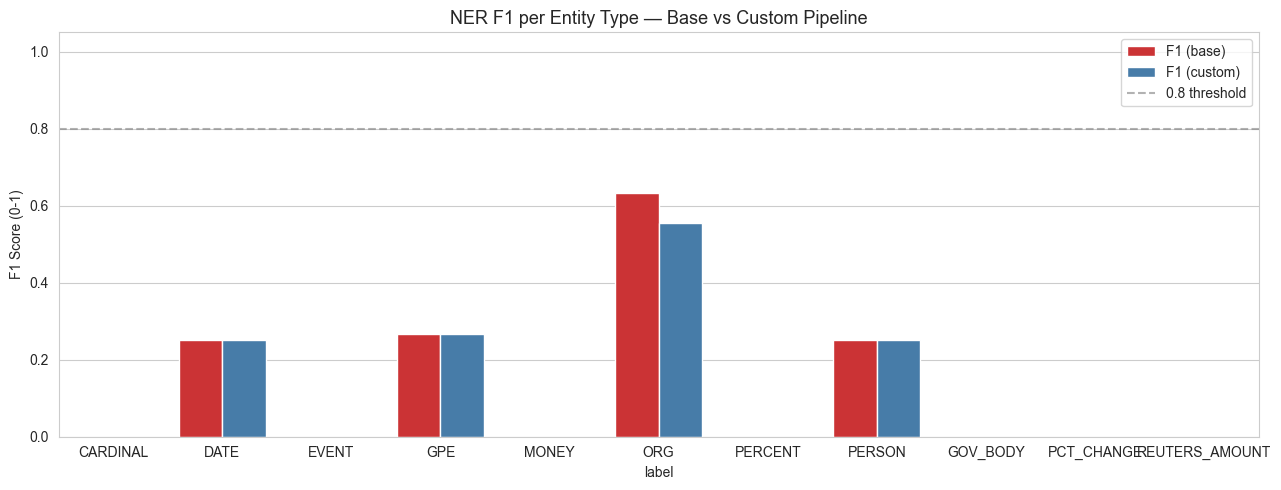

In [33]:
# ─── 12.3  Visualise evaluation results ──────────────────────

# Build a comparison DataFrame (exclude OVERALL row for the chart)
rows = []
for label, m in results_base.items():
    if label == 'OVERALL': continue
    rows.append({'label': label, 'metric': 'F1 (base)',   'score': m['f1']})
for label, m in results_custom.items():
    if label == 'OVERALL': continue
    rows.append({'label': label, 'metric': 'F1 (custom)', 'score': m['f1']})

eval_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=eval_df, x='label', y='score', hue='metric', palette='Set1', ax=ax)
ax.set_title('NER F1 per Entity Type — Base vs Custom Pipeline', fontsize=13)
ax.set_ylabel('F1 Score (0-1)')
ax.set_ylim(0, 1.05)
ax.axhline(0.8, color='grey', linestyle='--', alpha=0.6, label='0.8 threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
# ─── 12.4  Error analysis — what did the model get wrong? ────
# Understanding errors is as important as measuring metrics

print('Error Analysis — False Positives and False Negatives')
print('=' * 65)

for item in EVAL_SET:
    text   = item['text']
    gold   = set(item['entities'])
    doc    = nlp(text)
    pred   = {(e.start_char, e.end_char, e.label_) for e in doc.ents}

    false_positives = pred - gold   # model predicted but wrong
    false_negatives = gold - pred   # model missed

    if false_positives or false_negatives:
        print(f'Text: {text}')
        for (s, e, label) in false_positives:
            print(f'  FP (hallucinated): [{label}] "{text[s:e]}"')
        for (s, e, label) in false_negatives:
            print(f'  FN (missed):       [{label}] "{text[s:e]}"')
        print()

Error Analysis — False Positives and False Negatives
Text: General Motors said it will close its Detroit plant next year.
  FP (hallucinated): [GPE] "Detroit"
  FP (hallucinated): [DATE] "next year"
  FN (missed):       [GPE] " Detroi"

Text: IBM reported revenues of 2.3 bln dlrs in the first quarter of 1987.
  FP (hallucinated): [CARDINAL] "2.3"
  FP (hallucinated): [DATE] "the first quarter of 1987"
  FN (missed):       [DATE] "1987"
  FN (missed):       [MONEY] " 2.3 bln d"

Text: Federal Reserve chairman Paul Volcker told Congress the economy was stable.
  FP (hallucinated): [ORG] "Federal Reserve"
  FN (missed):       [ORG] "Federal Reserv"

Text: Japan and the United States signed a new trade agreement in Tokyo.
  FP (hallucinated): [GPE] "the United States"
  FN (missed):       [GPE] "United States"

Text: Texaco Inc filed for bankruptcy in April 1987 after losing a 10.5 bln dlr judgment.
  FP (hallucinated): [CARDINAL] "10.5"
  FN (missed):       [MONEY] " 10.5 bln dlr "

Text:

---
## Section 13 — End-to-End Pipeline

### Putting it all together

We now combine everything into a single reusable `NLPPipeline` class that:
1. Cleans raw text
2. Runs the full custom spaCy pipeline
3. Extracts structured output: entities, noun phrases, topic, SVO triples
4. Returns a clean Python dataclass

This is the pattern used in production document intelligence systems.

In [35]:
# ─── 13.1  Pipeline dataclass ────────────────────────────────
from dataclasses import dataclass, field
from typing import List, Tuple, Dict


@dataclass
class NLPResult:
    """
    Structured output from the NLP pipeline.
    All fields have defaults so the dataclass is always safe to construct.
    """
    raw_text:        str
    clean_text:      str = ''
    tokens:          List[str]                      = field(default_factory=list)
    sentences:       List[str]                      = field(default_factory=list)
    noun_phrases:    List[str]                      = field(default_factory=list)
    entities:        List[Dict]                     = field(default_factory=list)
    svo_triples:     List[Tuple[str, str, str]]     = field(default_factory=list)
    topic:           str                            = 'unknown'
    entity_density:  float                          = 0.0

    def summary(self):
        """Print a human-readable summary of this result."""
        print(f'[Topic: {self.topic} | Density: {self.entity_density}]')
        print(f'Tokens: {len(self.tokens)}  |  Sentences: {len(self.sentences)}')
        print(f'Entities ({len(self.entities)}):')
        for ent in self.entities:
            print(f'  [{ent["label"]}] "{ent["text"]}"')
        if self.svo_triples:
            print(f'SVO triples:')
            for s, v, o in self.svo_triples:
                print(f'  {s} --[{v}]--> {o}')

In [36]:
# ─── 13.2  NLPPipeline class ─────────────────────────────────

class NLPPipeline:
    """
    End-to-end NLP pipeline wrapping spaCy.

    Usage:
        pipe = NLPPipeline()
        result = pipe.process('Apple acquired Intel for $1 bln in January.')
        result.summary()
    """

    def __init__(self):
        # We reuse the custom pipeline built in previous sections
        self.nlp = nlp_custom

    def process(self, text: str) -> NLPResult:
        """Run the full pipeline on a single document."""

        # Step 1: Clean the text
        cleaned = clean_text(text, for_spacy=True)

        # Step 2: Run spaCy (tokenise, POS, parse, NER, EntityRuler,
        #                    topic_classifier, entity_density_scorer)
        doc = self.nlp(cleaned)

        # Step 3: Extract tokens (non-stop, alphabetic)
        tokens = [t.text for t in doc if t.is_alpha and not t.is_stop]

        # Step 4: Extract sentences
        sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 5]

        # Step 5: Extract noun phrases
        noun_phrases = list({chunk.text for chunk in doc.noun_chunks
                             if len(chunk.text.split()) > 1})  # multi-word phrases only

        # Step 6: Extract named entities as dicts
        entities = [
            {'text': ent.text, 'label': ent.label_, 'start': ent.start_char, 'end': ent.end_char}
            for ent in doc.ents
        ]

        # Step 7: Extract subject-verb-object triples
        svo = extract_svo(doc)

        # Step 8: Retrieve custom attributes set by pipeline components
        topic           = doc._.topic
        entity_density  = doc._.entity_density

        return NLPResult(
            raw_text       = text,
            clean_text     = cleaned,
            tokens         = tokens,
            sentences      = sentences,
            noun_phrases   = noun_phrases,
            entities       = entities,
            svo_triples    = svo,
            topic          = topic,
            entity_density = entity_density,
        )

    def process_batch(self, texts: List[str]) -> List[NLPResult]:
        """Process a list of documents efficiently using nlp.pipe."""
        cleaned = [clean_text(t) for t in texts]
        results = []
        for doc, raw in tqdm(zip(self.nlp.pipe(cleaned, batch_size=64), texts),
                             total=len(texts), desc='Processing'):
            results.append(NLPResult(
                raw_text       = raw,
                clean_text     = doc.text,
                tokens         = [t.text for t in doc if t.is_alpha and not t.is_stop],
                sentences      = [s.text.strip() for s in doc.sents],
                noun_phrases   = [c.text for c in doc.noun_chunks if len(c.text.split()) > 1],
                entities       = [{'text': e.text, 'label': e.label_} for e in doc.ents],
                svo_triples    = extract_svo(doc),
                topic          = doc._.topic,
                entity_density = doc._.entity_density,
            ))
        return results


# Initialise the pipeline
pipeline = NLPPipeline()
print('Pipeline ready.')

Pipeline ready.


In [37]:
# ─── 13.3  Run the pipeline on real news documents ────────────

test_news = [
    # Reuters M&A article
    ("Reuters: General Electric agreed to acquire Honeywell International "
     "for 42 bln dlrs. The European Commission may block the deal. "
     "GE CEO Jack Welch confirmed the merger in New York on Monday."),

    # 20 Newsgroups space discussion
    ("NASA's Hubble Space Telescope discovered evidence of water vapour "
     "on Jupiter's moon Europa last Thursday. Scientists at JPL and ESA "
     "celebrated the finding as a major step toward the Artemis mission."),

    # Politics article
    ("Senator John Kerry of Massachusetts argued in Congress that the "
     "Clinton administration's trade policy toward China was undermining "
     "American jobs. The Senate vote is expected in December."),
]

for text in test_news:
    print('─' * 70)
    result = pipeline.process(text)
    result.summary()
    print()

──────────────────────────────────────────────────────────────────────
[Topic: finance | Density: 0.457]
Tokens: 22  |  Sentences: 3
Entities (9):
  [ORG] "Reuters"
  [ORG] "General Electric"
  [ORG] "Honeywell International"
  [REUTERS_AMOUNT] "42 bln"
  [ORG] "The European Commission"
  [ORG] "GE"
  [PERSON] "Jack Welch"
  [GPE] "New York"
  [DATE] "Monday"
SVO triples:
  Commission --[block]--> deal
  Welch --[confirm]--> merger

──────────────────────────────────────────────────────────────────────
[Topic: space | Density: 0.314]
Tokens: 21  |  Sentences: 2
Entities (8):
  [ORG] "NASA"
  [FAC] "Hubble Space Telescope"
  [LOC] "Jupiter"
  [LOC] "Europa"
  [DATE] "last Thursday"
  [ORG] "JPL"
  [ORG] "ESA"
  [NORP] "Artemis"
SVO triples:
  Telescope --[discover]--> evidence
  Scientists --[celebrate]--> finding

──────────────────────────────────────────────────────────────────────
[Topic: politics | Density: 0.3]
Tokens: 18  |  Sentences: 2
Entities (8):
  [PERSON] "John Kerry"
  [G

Processing: 100%|██████████| 200/200 [00:01<00:00, 142.77it/s]

Batch processing results:
  Processed    : 200 documents
  Avg entities : 6.5 per document
  Avg density  : 0.248



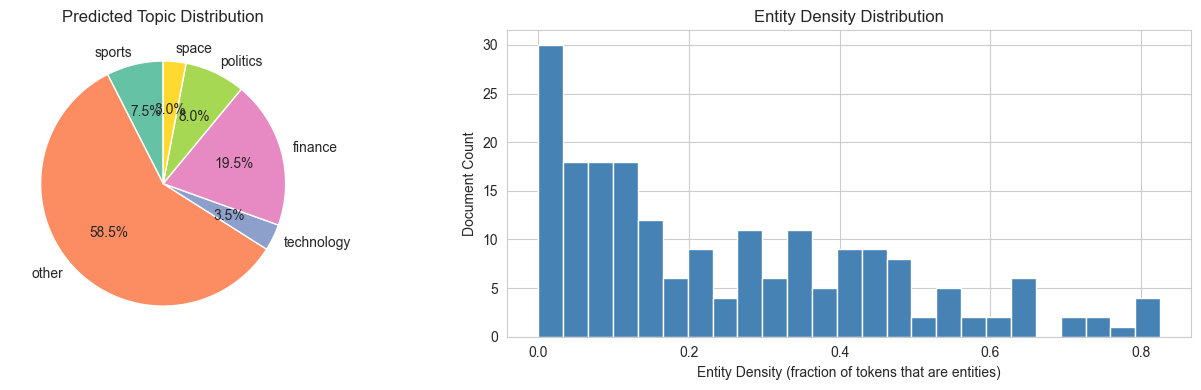

In [38]:
# ─── 13.4  Batch processing the real corpus ──────────────────
# Process a sample of the real corpus and inspect the results

SAMPLE_SIZE = 200
sample_texts = [d['clean_text'][:400] for d in ALL_DOCS[:SAMPLE_SIZE]]

# Batch process — much faster than one-by-one
batch_results = pipeline.process_batch(sample_texts)

# Aggregate statistics
topics        = [r.topic for r in batch_results]
densities     = [r.entity_density for r in batch_results]
entity_counts = [len(r.entities) for r in batch_results]

print('Batch processing results:')
print(f'  Processed    : {len(batch_results)} documents')
print(f'  Avg entities : {np.mean(entity_counts):.1f} per document')
print(f'  Avg density  : {np.mean(densities):.3f}')
print()

# Plot topic distribution
topic_counts = Counter(topics)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Topic pie chart
axes[0].pie(topic_counts.values(), labels=topic_counts.keys(),
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
axes[0].set_title('Predicted Topic Distribution')

# Entity density histogram
axes[1].hist(densities, bins=25, color='steelblue', edgecolor='white')
axes[1].set_title('Entity Density Distribution')
axes[1].set_xlabel('Entity Density (fraction of tokens that are entities)')
axes[1].set_ylabel('Document Count')

plt.tight_layout()
plt.show()

---
## Summary

In this notebook you built a **complete spaCy NLP pipeline** on real data from two public corpora:

| Step | What you did | Key concept |
|------|-------------|------------|
| Data loading | 20 Newsgroups + Reuters via sklearn/NLTK | Real corpora, class imbalance |
| Cleaning | Removed headers, URLs, email addresses | Minimal cleaning for NER |
| Exploration | Length distribution, word cloud, class counts | EDA before modelling |
| spaCy architecture | Doc object, pipeline components | How text flows through a pipeline |
| Tokenisation | spaCy vs. naive split | Rule-based tokenisation |
| POS tagging | Token attributes, noun chunks | Coarse vs. fine-grained tags |
| Dependency parsing | SVO triple extraction | Grammatical relations |
| NER | Entity types, displacy visualisation | BIO tagging, OntoNotes labels |
| EntityRuler | Custom ticker/amount/gov patterns | Rule-based + statistical hybrid |
| Custom components | Topic classifier, entity density | `@Language.component`, `Doc.set_extension` |
| Evaluation | Precision/Recall/F1 per type, error analysis | Exact-match span evaluation |
| End-to-end | `NLPPipeline` class with batch processing | Production-ready patterns |

---

## Next steps

1. **Fine-tune the NER model** on Reuters using spaCy's `spacy train` command and the CoNLL 2003 format
2. **Add a `TextCategorizer`** component trained on the 20 Newsgroups labels for higher accuracy topic classification
3. **Use `en_core_web_md` or `en_core_web_lg`** for better NER accuracy (larger word vectors)
4. **Chain with a transformer model** via `spacy-transformers` for state-of-the-art results
5. **Export the pipeline** with `nlp.to_disk('my_pipeline/')` and reload it in a FastAPI service